In [1]:
import csv
import nibabel as nib
import matplotlib.pyplot as plt
import random
import torch
import os
import numpy as np
from model1 import CNN_3D,NiiDataset,MultiModalTransformer,NeuralNet,KGMultiModalTransformer
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import nibabel as nib
import shutil
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import math
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import pandas as pd

In [2]:
#生物标志物 ad 90*48   no 349*58
path_existence = []
data_normal=[]
data_ad=[]
data_mci=[]
count_ad=0
count_no=0
count_mci=0
with open('normal.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader)  
    for row in csv_reader:
        path = 'E:/code/ADNI/normal_nii_kg/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_no=count_no+1
            data_normal.append(row)
            
with open('AD.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/ADNI/ad_nii_KG/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_ad=count_ad+1
            data_ad.append(row)
            
with open('mci.csv', mode='r', newline='', encoding='utf-8') as file:
    csv_reader = csv.reader(file)
    next(csv_reader) 
    for row in csv_reader:
        path = 'E:/code/ADNI/NC_nii_KG/' + row[1]
        exists = os.path.exists(path)
        path_existence.append((path, exists))
        if exists:
            count_mci=count_mci+1
            data_mci.append(row)
print(count_ad) #151
print(count_no) #211
print(count_mci) #475

151
211
475


In [ ]:

# 基础替换字典
replace_dict = {'female': '0', 'male': '1', 'whi': '0', 'blk': '1', '': '0','ind':'3','ans':'4'}

# 隔离诊断标签的列索引提取规则
# EHR (14维): age(2), gender(3), education(4), hispanic(5), race(6) + his_系列(57-65)
ehr_cols = [2, 3, 4, 5, 6, 57, 58, 59, 60, 61, 62, 63, 64, 65] 
# BIO (39维): apoe(7) + mmse/cdr(20-22) + gds/moca(66, 67) + trail/npiq/faq等(24-56)
bio_cols = [7, 20, 21, 22, 66, 67] + list(range(24, 57))

# 统一且安全的预处理函数
# 统一且安全的预处理函数
def preprocess_data(data, replace_dict, target_cols):
    processed_data = []
    for row in data:
        # 仅提取安全的特征列
        extracted_row = [row[idx] for idx in target_cols]
        # 字典映射替换
        extracted_row = [replace_dict.get(item, item) for item in extracted_row]
        
        numerical_row = []
        for item in extracted_row:
            try:
                val = float(item)
                # 拦截 NaN，保留为 np.nan 供后续专门的 Imputer 处理
                if math.isnan(val):
                    val = np.nan
            except ValueError:
                val = np.nan 
            numerical_row.append(val)
            
        processed_data.append(numerical_row)
    return np.array(processed_data)

# 加权算值函数 (保留你的原始定义)
def weighted_sum(tensor):
    weights = [0.2, 0.3, 0.5]
    weight_tensor = torch.tensor(weights, dtype=tensor.dtype, device=tensor.device)
    weighted_sum_result = torch.sum(tensor * weight_tensor, dim=1, keepdim=True)
    return weighted_sum_result

In [4]:
# 1. 提取 BIO 数组 (真实的 39 维特征)
ad_array = preprocess_data(data_ad, replace_dict, bio_cols)
normal_array = preprocess_data(data_normal, replace_dict, bio_cols)
mci_array = preprocess_data(data_mci, replace_dict, bio_cols)

# 2. 直接转换数据为 Tensor (无需外部线性层)
ad_tensor = torch.from_numpy(ad_array).float()
normal_tensor = torch.from_numpy(normal_array).float()
mci_tensor = torch.from_numpy(mci_array).float()

# 3. 打印结果 (预期输出类似: torch.Size([151, 39]))
print('AD_tensor shape:', ad_tensor.shape)      
print('Normal_tensor shape:', normal_tensor.shape) 
print('MCI_tensor shape:', mci_tensor.shape)

AD_tensor shape: torch.Size([151, 39])
Normal_tensor shape: torch.Size([211, 39])
MCI_tensor shape: torch.Size([475, 39])


In [5]:
# 1. 提取脱敏后的 EHR 数组 (内部已通过 replace_dict 转换为数值)
ad_data = preprocess_data(data_ad, replace_dict, ehr_cols)
normal_data = preprocess_data(data_normal, replace_dict, ehr_cols)
mci_data = preprocess_data(data_mci, replace_dict, ehr_cols)

# 2. 直接转换为 Tensor (无需外部线性层)
ad_EHR = torch.from_numpy(ad_data).float()
normal_EHR = torch.from_numpy(normal_data).float()
mci_EHR = torch.from_numpy(mci_data).float()

# 3. 打印结果 (预期输出类似: torch.Size([151, 14]))
print('ad.EHR--->', ad_EHR.shape)
print('normal.EHR--->', normal_EHR.shape)
print('mci.EHR--->', mci_EHR.shape)

ad.EHR---> torch.Size([151, 14])
normal.EHR---> torch.Size([211, 14])
mci.EHR---> torch.Size([475, 14])


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
import torch
from torch.utils.data import DataLoader

# 1. 实例化模型，将输出维度设为64，以严格匹配 Transformer 的 img_dim=64
nii = CNN_3D(num_class=64)
nii = nii.to(device)
nii.eval() # 开启评估模式，冻结网络行为

def extract_mri_features(folder_path, batch_size=16):
    dataset = NiiDataset(folder_path)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_outputs = []
    
    # 2. 极其重要：关闭梯度计算，大幅节省显存并加快提取速度
    with torch.no_grad():
        for batch_idx, batch_data in enumerate(dataloader):
            batch_data = batch_data.to(device)
            output = nii(batch_data)
            # 提取后立即转回 CPU，防止 GPU 显存堆积
            all_outputs.append(output.cpu())
            
    return torch.cat(all_outputs, dim=0)

all_ad = 'E:/code/ADNI/ad_nii_KG/'
all_normal = 'E:/code/ADNI/normal_nii_kg/'
all_mci = 'E:/code/ADNI/NC_nii_KG/'

# 3. 模块化调用
ad_output = extract_mri_features(all_ad)
print('ad nii shape--->', ad_output.shape)

normal_output = extract_mri_features(all_normal)
print('normal nii shape--->', normal_output.shape)

mci_output = extract_mri_features(all_mci)
print('mci nii shape--->', mci_output.shape)

ad nii shape---> torch.Size([151, 64])
normal nii shape---> torch.Size([211, 64])
mci nii shape---> torch.Size([475, 64])


In [8]:
import numpy as np
import torch
import pandas as pd
import json

# 保持你的路径配置不变
ENTITY_EMB_NPY = "ADNI-DementiaHKG-Embeddings.npy"
ENTITY2ID_FILE = "ADNI-DementiaHKG-Entity2ID.json"
PATIENT_QUERY_DICT = "ADNI-DementiaHKG-Entities.json"

with open(ENTITY2ID_FILE, 'r', encoding='utf-8') as f:
    entity2id = json.load(f)

with open(PATIENT_QUERY_DICT, 'r', encoding='utf-8') as f:
    patient_entities = json.load(f)

emb = torch.from_numpy(np.load(ENTITY_EMB_NPY)).float()
embed_dim = emb.shape[1] 
max_seq_len = 35 

def get_patient_embedding_seq(filename: str):
    filename = str(filename).strip()
    patient_data = patient_entities.get(filename, {})
    active_nodes = patient_data.get("input_nodes", [])
    
    vecs = []
    pad_masks = []
    
    # 构造固定长度为35的序列与对应的布尔掩码
    for i in range(max_seq_len):
        if i < len(active_nodes):
            node = active_nodes[i]
            if node != "[PAD]" and node in entity2id:
                vecs.append(emb[entity2id[node]])
                pad_masks.append(False) 
            else:
                vecs.append(torch.zeros(embed_dim))
                pad_masks.append(True) 
        else:
            vecs.append(torch.zeros(embed_dim))
            pad_masks.append(True)
            
    # 返回知识序列矩阵和用于PyTorch注意力的掩码
    return torch.stack(vecs), torch.tensor(pad_masks, dtype=torch.bool)

def process_and_verify_seq(df, cohort_name):
    seq_tensors = []
    mask_tensors = []
    valid_count = 0
    
    for _, r in df.iterrows():
        seq_tensor, mask_tensor = get_patient_embedding_seq(r['filename'])
        seq_tensors.append(seq_tensor)
        mask_tensors.append(mask_tensor)
        
        # 验证是否包含至少一个有效节点（掩码中存在False）
        if not torch.all(mask_tensor):
            valid_count += 1
            
    stacked_seq = torch.stack(seq_tensors)
    stacked_mask = torch.stack(mask_tensors)
    
    print(f"[{cohort_name}] 总样本数: {len(df)} | 成功注入KG先验序列的样本数: {valid_count}")
    return stacked_seq, stacked_mask

# 执行数据提取
print("开始提取完整知识序列与注意力掩码...")
ad_transe_seq, ad_transe_mask = process_and_verify_seq(pd.read_csv('AD.csv'), "AD")
mci_transe_seq, mci_transe_mask = process_and_verify_seq(pd.read_csv('mci.csv'), "MCI")
nc_transe_seq, nc_transe_mask = process_and_verify_seq(pd.read_csv('normal.csv'), "NC")

print("最终生成的知识序列 Shapes:", ad_transe_seq.shape, mci_transe_seq.shape, nc_transe_seq.shape)
print("最终生成的掩码张量 Shapes:", ad_transe_mask.shape, mci_transe_mask.shape, nc_transe_mask.shape)

开始提取完整知识序列与注意力掩码...
[AD] 总样本数: 151 | 成功注入KG先验序列的样本数: 151
[MCI] 总样本数: 475 | 成功注入KG先验序列的样本数: 474
[NC] 总样本数: 211 | 成功注入KG先验序列的样本数: 196
最终生成的知识序列 Shapes: torch.Size([151, 35, 128]) torch.Size([475, 35, 128]) torch.Size([211, 35, 128])
最终生成的掩码张量 Shapes: torch.Size([151, 35]) torch.Size([475, 35]) torch.Size([211, 35])


In [9]:
# 第一步：合并原有的多模态特征 (EHR + IMG + BIO)
features_ad = torch.cat([ad_EHR, ad_output.cpu(), ad_tensor], dim=1)
features_mci = torch.cat([mci_EHR, mci_output.cpu(), mci_tensor], dim=1)
features_normal = torch.cat([normal_EHR, normal_output.cpu(), normal_tensor], dim=1)

# 第二步：沿着批次维度(dim=0)纵向合并所有样本的特征
features = torch.cat([features_ad, features_mci, features_normal], dim=0).float()

# 第三步：纵向合并上一步提取的所有样本的知识序列矩阵
kg_seq = torch.cat([ad_transe_seq, mci_transe_seq, nc_transe_seq], dim=0).float()

# 第四步：纵向合并对应的知识掩码矩阵
kg_mask = torch.cat([ad_transe_mask, mci_transe_mask, nc_transe_mask], dim=0).bool()

# 第五步：生成类别标签
y_ad = torch.ones(len(features_ad)) * 2  # AD 类别标签为 2
y_mci = torch.ones(len(features_mci)) * 1  # MCI 类别标签为 1
y_normal = torch.ones(len(features_normal)) * 0  # NC 类别标签为 0

# 分类任务的标签通常建议使用 long 类型
y = torch.cat([y_ad, y_mci, y_normal], dim=0).long() 

print("多模态特征 (features) 维度:", features.shape)
print("知识序列 (kg_seq) 维度:", kg_seq.shape)
print("注意力掩码 (kg_mask) 维度:", kg_mask.shape)
print("标签 (y) 维度:", y.shape)

多模态特征 (features) 维度: torch.Size([837, 117])
知识序列 (kg_seq) 维度: torch.Size([837, 35, 128])
注意力掩码 (kg_mask) 维度: torch.Size([837, 35])
标签 (y) 维度: torch.Size([837])


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.impute import SimpleImputer
import torch



# 1. 正常的划分数据集：同时切分特征(features), 图谱序列(kg_seq), 掩码(kg_mask) 和 标签(y)
# ★★★ 修复 NaN 报错的核心代码：防止全填充序列导致 Attention Softmax 除零崩溃 ★★★
# 找到那些掩码一整行全为 True 的样本（完全没有图谱节点的健康人）
all_padded_idx = kg_mask.all(dim=1)
# 强行把这些样本的第0个位置的掩码设为 False，使其能够去关注一个全零的 Padding 向量
kg_mask[all_padded_idx, 0] = False

X_train, X_test, seq_train, seq_test, mask_train, mask_test, y_train, y_test = train_test_split(
    features.detach().numpy(), 
    kg_seq.detach().numpy(), 
    kg_mask.detach().numpy(), 
    y.numpy(),
    test_size=0.20,
    stratify=y.numpy(),
    random_state=32
)


X_train, X_val, seq_train, seq_val, mask_train, mask_val, y_train, y_val = train_test_split(
    X_train, seq_train, mask_train, y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=30
)

# ----------------- 缺失值填充与归一化模块 -----------------
# 2. 初始化填充器和标准化器
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

# 3. 仅在训练集的“多模态特征(X)”上进行 fit_transform，严防数据泄露。图谱序列和掩码无需处理。
X_train = imputer.fit_transform(X_train)
X_train = scaler.fit_transform(X_train)

# 4. 在验证集和测试集上仅进行 transform
X_val = imputer.transform(X_val)
X_val = scaler.transform(X_val)

X_test = imputer.transform(X_test)
X_test = scaler.transform(X_test)
# ----------------------------------------------------

# 5. 转为 Tensor 并构建 DataLoader
X_train_tensor = torch.FloatTensor(X_train).to(device)
seq_train_tensor = torch.FloatTensor(seq_train).to(device)
mask_train_tensor = torch.BoolTensor(mask_train).to(device) # 注意掩码用 BoolTensor
y_train_tensor = torch.LongTensor(y_train).to(device)  

X_val_tensor = torch.FloatTensor(X_val).to(device)
seq_val_tensor = torch.FloatTensor(seq_val).to(device)
mask_val_tensor = torch.BoolTensor(mask_val).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)

X_test_tensor = torch.FloatTensor(X_test).to(device)
seq_test_tensor = torch.FloatTensor(seq_test).to(device)
mask_test_tensor = torch.BoolTensor(mask_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# 将 4 个张量打包进入 Dataset
train_dataset = TensorDataset(X_train_tensor, seq_train_tensor, mask_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, seq_val_tensor, mask_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, seq_test_tensor, mask_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [11]:
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    
    # 修改点：解包 4 个变量
    for inputs, kg_seq, kg_mask, labels in loader:
        inputs = inputs.to(device)
        kg_seq = kg_seq.to(device)
        kg_mask = kg_mask.to(device)
        labels = labels.to(device).long()
        
        optimizer.zero_grad()
        # 修改点：将特征、知识序列、掩码传入模型
        outputs = model(inputs, kg_seq, kg_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

        probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
        preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds)

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    train_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    train_f1 = f1_score(all_labels, all_preds, average='macro')
    train_recall = recall_score(all_labels, all_preds, average='macro')
    train_precision = precision_score(all_labels, all_preds, average='macro')

    avg_loss = total_loss / len(loader)
    return avg_loss, train_auc, train_f1, train_recall, train_precision

def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_probs = []
    all_labels = []
    all_preds = []
    with torch.no_grad():
        # 修改点：解包 4 个变量
        for inputs, kg_seq, kg_mask, labels in loader:
            inputs = inputs.to(device)
            kg_seq = kg_seq.to(device)
            kg_mask = kg_mask.to(device)
            labels = labels.to(device).long()
            
            # 修改点：将特征、知识序列、掩码传入模型
            outputs = model(inputs, kg_seq, kg_mask)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1).detach().cpu().numpy()
            preds = torch.argmax(outputs, dim=1).detach().cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds)
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    val_auc = roc_auc_score(all_labels, all_probs, multi_class='ovo')
    val_f1 = f1_score(all_labels, all_preds, average='macro')
    val_recall = recall_score(all_labels, all_preds, average='macro')
    val_precision = precision_score(all_labels, all_preds, average='macro')
    
    avg_loss = total_loss / len(loader)
    return avg_loss, val_auc, val_f1, val_recall, val_precision

In [17]:
import torch.optim as optim
import torch.nn as nn

embed_dim        = 128
transe_embed_dim = 128           
num_epochs       = 200
batch_size       = 32
learning_rate    = 1e-5
weight_decay     = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 初始化模型 (调用刚刚升级好的模态感知检索版)
model = KGMultiModalTransformer(
            embed_dim=embed_dim,
            transe_embed_dim=transe_embed_dim
        ).to(device)

criterion  = nn.CrossEntropyLoss()
optimizer  = optim.Adam(model.parameters(),
                        lr=learning_rate,
                        weight_decay=weight_decay)

train_losses  = []; train_aucs  = []; train_f1s  = []
train_recalls = []; train_precisions = []
test_losses   = []; test_aucs   = []; test_f1s   = []
test_recalls  = []; test_precisions  = []

for epoch in range(num_epochs):
    tr_loss, tr_auc, tr_f1, tr_rec, tr_prec = train_epoch(
        model, train_loader, optimizer, criterion, device)
    
    # 原代码这里写的是 validate_epoch 却传入了 test_loader，我保留你的原逻辑
    te_loss, te_auc, te_f1, te_rec, te_prec = validate_epoch(
        model, test_loader,  criterion, device)

    train_losses.append(tr_loss);    test_losses.append(te_loss)
    train_aucs.append(tr_auc);       test_aucs.append(te_auc)
    train_f1s.append(tr_f1);         test_f1s.append(te_f1)
    train_recalls.append(tr_rec);    test_recalls.append(te_rec)
    train_precisions.append(tr_prec);test_precisions.append(te_prec)

    if epoch % 10 == 0: print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss {tr_loss:.4f}  AUC {tr_auc:.4f} | "
          f"Test Loss {te_loss:.4f}   AUC {te_auc:.4f}")

Epoch 1/200 | Train Loss 1.0862  AUC 0.4843 | Test Loss 1.0928   AUC 0.5695
Epoch 2/200 | Train Loss 1.0667  AUC 0.5192 | Test Loss 1.0813   AUC 0.5996
Epoch 3/200 | Train Loss 1.0662  AUC 0.5138 | Test Loss 1.0726   AUC 0.6264
Epoch 4/200 | Train Loss 1.0481  AUC 0.5398 | Test Loss 1.0630   AUC 0.6459
Epoch 5/200 | Train Loss 1.0536  AUC 0.5189 | Test Loss 1.0502   AUC 0.6637
Epoch 6/200 | Train Loss 1.0584  AUC 0.5087 | Test Loss 1.0492   AUC 0.6734
Epoch 7/200 | Train Loss 1.0265  AUC 0.5597 | Test Loss 1.0561   AUC 0.6936
Epoch 8/200 | Train Loss 1.0141  AUC 0.5864 | Test Loss 1.0506   AUC 0.6972
Epoch 9/200 | Train Loss 1.0084  AUC 0.5975 | Test Loss 1.0401   AUC 0.7149
Epoch 10/200 | Train Loss 1.0142  AUC 0.5911 | Test Loss 1.0348   AUC 0.7234
Epoch 11/200 | Train Loss 1.0029  AUC 0.6156 | Test Loss 1.0324   AUC 0.7488
Epoch 12/200 | Train Loss 0.9977  AUC 0.6096 | Test Loss 1.0171   AUC 0.7617
Epoch 13/200 | Train Loss 0.9758  AUC 0.6439 | Test Loss 1.0331   AUC 0.7645
Epoch 14

In [21]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import torch

model.eval()
all_probs = []
all_labels = []
with torch.no_grad():
    # ★ 修改点：从 loader 中解包出 4 个变量
    for inputs, kg_seq, kg_mask, labels in val_loader:
        inputs = inputs.to(device)
        kg_seq = kg_seq.to(device)
        kg_mask = kg_mask.to(device)
        labels = labels.to(device).long()
        
        # ★ 修改点：模型现在接收特征、图谱序列和掩码三个输入
        outputs = model(inputs, kg_seq, kg_mask)
        
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.cpu().numpy())

preds = np.argmax(all_probs, axis=1)
accuracy = accuracy_score(all_labels, preds)
precision = precision_score(all_labels, preds, average='macro')
recall = recall_score(all_labels, preds, average='macro')
f1 = f1_score(all_labels, preds, average='macro')
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print("\n=== Final Validation Metrics ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f}")


=== Final Validation Metrics ===
Accuracy:  0.8284
Precision: 0.8340
Recall:    0.7798
F1 Score:  0.8018
AUC-ROC:   0.9468


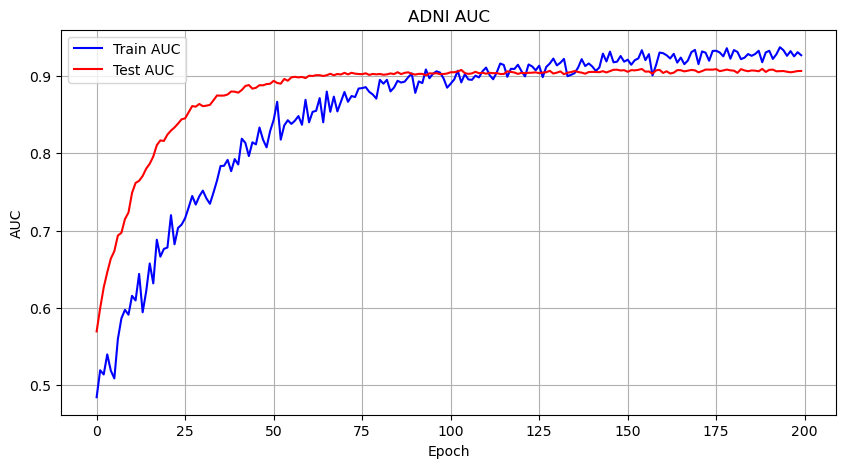

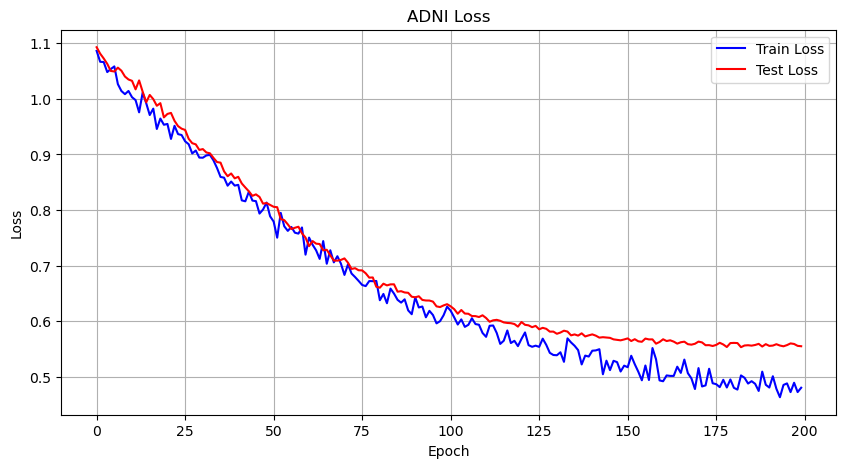

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(range(len(train_aucs)), train_aucs, label="Train AUC", color="blue")
plt.plot(range(len(test_aucs)), test_aucs, label="Test AUC", color="red")
plt.title("ADNI AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)
plt.savefig('ADNI_DementiaHKG_plot.png', dpi=300)
plt.close()

plt.figure(figsize=(10, 5))
plt.plot(range(len(train_losses)), train_losses, label="Train Loss", color="blue")
plt.plot(range(len(test_losses)), test_losses, label="Test Loss", color="red")
plt.title("ADNI Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig('ADNI_DementiaHKG_plot.png', dpi=300)
plt.close()

In [20]:
from torchinfo import summary
import torch

# 1. 确保模型处于正确的设备上
model = model.to(device)

# 2. 构造与实际训练时维度相同的虚拟输入 (以 batch_size=32 为例)
# x 维度 = 14 (EHR) + 64 (img) + 39 (bio) = 117
dummy_x = torch.randn(32, 117).to(device)

# ★★★ 修改点：构造三维的知识序列和布尔型掩码 ★★★
# kg_seq 维度 = [batch_size, max_seq_len, embed_dim] = [32, 35, 128]
dummy_seq = torch.randn(32, 35, 128).to(device)

# kg_mask 维度 = [batch_size, max_seq_len] = [32, 35]，布尔型数据 (False代表有效节点)
dummy_mask = torch.zeros(32, 35, dtype=torch.bool).to(device)

# 3. 使用 torchinfo 打印模型详细结构和参数量
model_stats = summary(
    model, 
    input_data=(dummy_x, dummy_seq, dummy_mask), # ★ 修改点：传入三个虚拟参数
    col_names=["input_size", "output_size", "num_params", "trainable"],
    verbose=1
)

print(model_stats)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
KGMultiModalTransformer                  [32, 117]                 [32, 3]                   --                        True
├─Sequential: 1-1                        [32, 14]                  [32, 128]                 --                        True
│    └─Linear: 2-1                       [32, 14]                  [32, 16]                  240                       True
│    └─BatchNorm1d: 2-2                  [32, 16]                  [32, 16]                  32                        True
│    └─ReLU: 2-3                         [32, 16]                  [32, 16]                  --                        --
│    └─Dropout: 2-4                      [32, 16]                  [32, 16]                  --                        --
│    └─Linear: 2-5                       [32, 16]                  [32, 128]                 2,176                     True
│    └─